In [59]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix



- # **Load Dataset:**

In [60]:
df = pd.read_csv('wine_dataset.csv')
print(df.head(5))

   alcohol  malic_acid   ash  ...  diluted_wines  proline  target
0    14.23        1.71  2.43  ...           3.92     1065       0
1    13.20        1.78  2.14  ...           3.40     1050       0
2    13.16        2.36  2.67  ...           3.17     1185       0
3    14.37        1.95  2.50  ...           3.45     1480       0
4    13.24        2.59  2.87  ...           2.93      735       0

[5 rows x 14 columns]


- # **Data Overview:**

In [61]:
print('DATA SHAPE:\n',df.shape)
print('=============================================')
print('DATA COLUMNS:\n',df.columns)
print('=============================================')
print('DATA INFOMATION:\n', df.info())
print('=============================================')
print('DATA DESCRIPTION:\n', df.describe())
print('=============================================')
print('CHECK SKEWNESS:\n',df.skew(numeric_only=True))


DATA SHAPE:
 (178, 14)
DATA COLUMNS:
 Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue', 'diluted_wines', 'proline',
       'target'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   alcohol               178 non-null    float64
 1   malic_acid            178 non-null    float64
 2   ash                   178 non-null    float64
 3   alcalinity_of_ash     178 non-null    float64
 4   magnesium             178 non-null    int64  
 5   total_phenols         178 non-null    float64
 6   flavanoids            178 non-null    float64
 7   nonflavanoid_phenols  178 non-null    float64
 8   proanthocyanins       178 non-null    float64
 9   color_intensity       178 non-null    float64
 10 

- # **Data Prepocessing:**

In [62]:
print('MISSING VALUE IN THE DATASET:\n', df.isnull().sum())
print('=============================================')
print('DUPLICATED VALES IN DATASET:\n',df.duplicated().sum())

MISSING VALUE IN THE DATASET:
 alcohol                 0
malic_acid              0
ash                     0
alcalinity_of_ash       0
magnesium               0
total_phenols           0
flavanoids              0
nonflavanoid_phenols    0
proanthocyanins         0
color_intensity         0
hue                     0
diluted_wines           0
proline                 0
target                  0
dtype: int64
DUPLICATED VALES IN DATASET:
 0


# **Exploratory Data Analysis(EDA):**

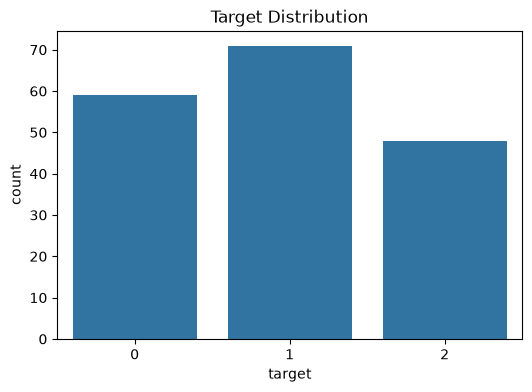

In [63]:
plt.figure(figsize=(6,4))
sns.countplot(x='target',data=df)
plt.title("Target Distribution")

plt.show()

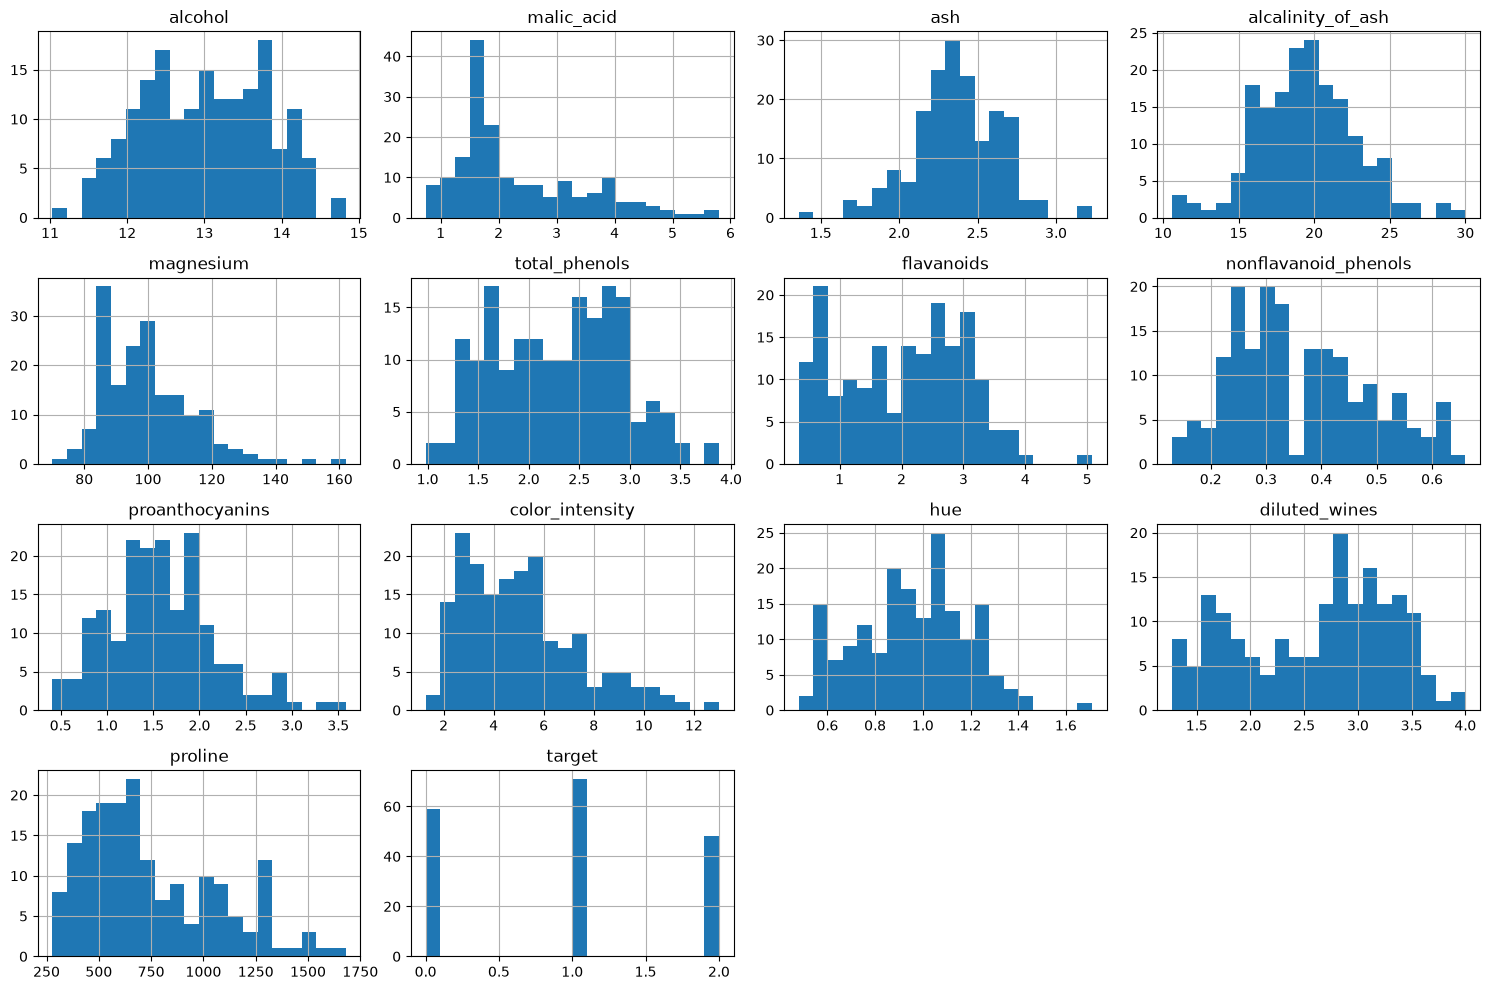

In [64]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

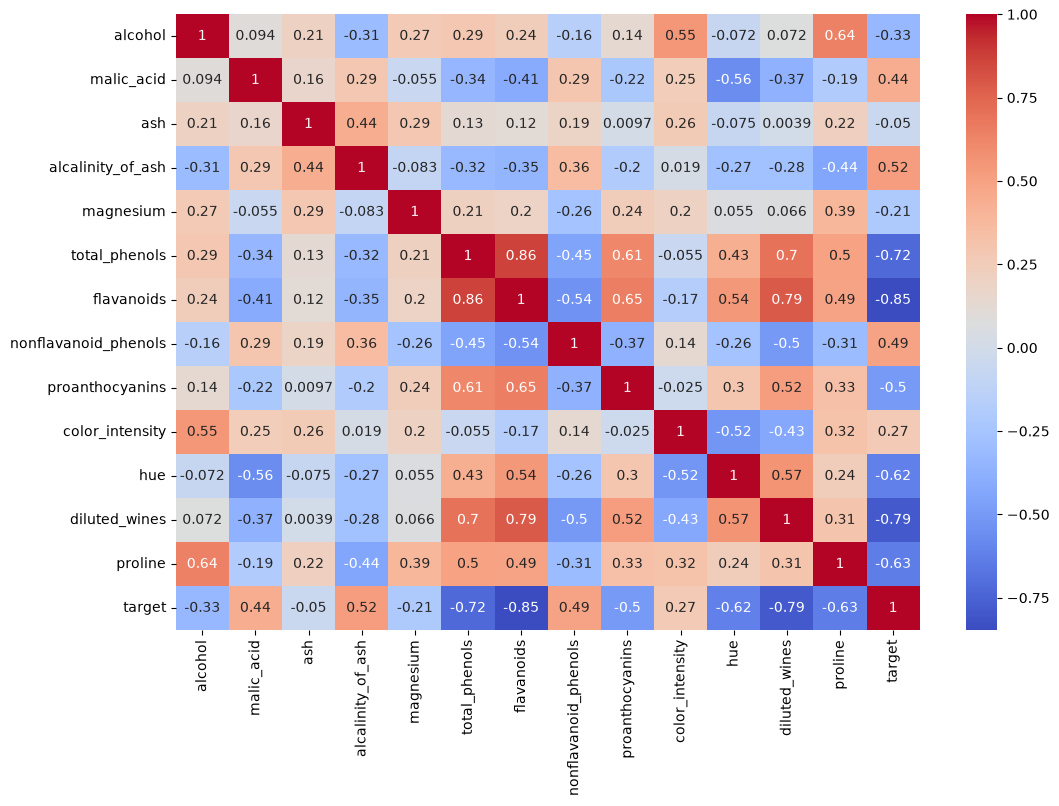

In [65]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

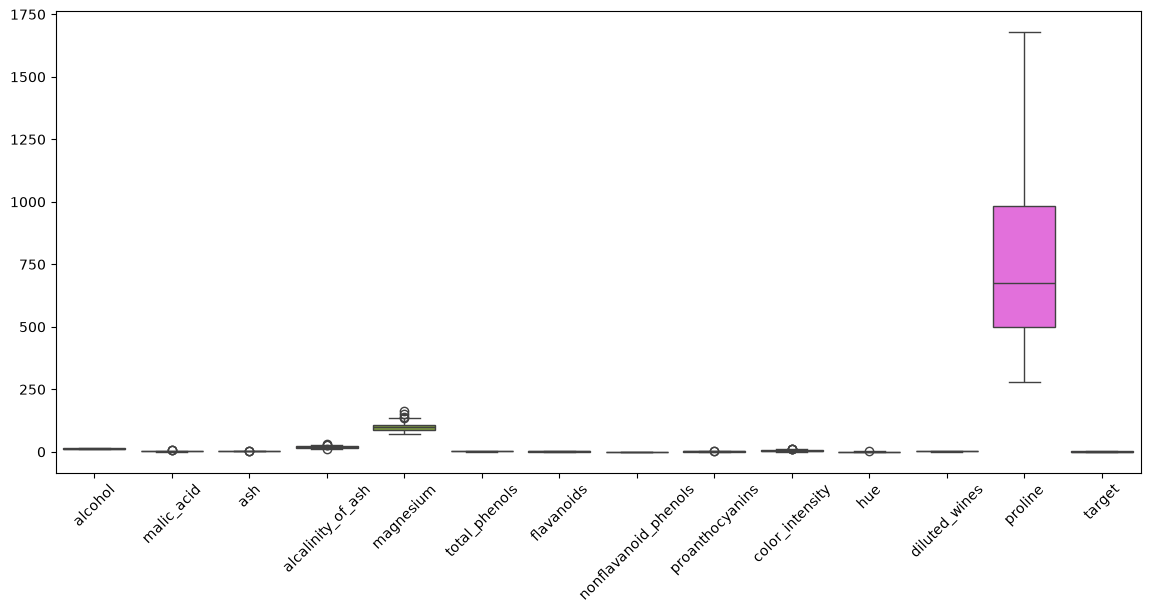

In [66]:
plt.figure(figsize=(14,6))

sns.boxplot(data=df)

plt.xticks(rotation=45)

plt.show()

In [67]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("TRAINING DATA:\n", X_train)
print("TESTING DATA:\n", X_test)

TRAINING DATA:
      alcohol  malic_acid   ash  ...   hue  diluted_wines  proline
158    14.34        1.68  2.70  ...  0.57           1.96      660
137    12.53        5.51  2.64  ...  0.82           1.69      515
98     12.37        1.07  2.10  ...  1.04           2.77      660
159    13.48        1.67  2.64  ...  0.57           1.78      620
38     13.07        1.50  2.10  ...  1.18           2.69     1020
..       ...         ...   ...  ...   ...            ...      ...
71     13.86        1.51  2.67  ...  1.36           3.16      410
106    12.25        1.73  2.12  ...  1.00           3.17      510
14     14.38        1.87  2.38  ...  1.20           3.00     1547
92     12.69        1.53  2.26  ...  0.96           2.06      495
102    12.34        2.45  2.46  ...  0.80           3.38      438

[142 rows x 13 columns]
TESTING DATA:
      alcohol  malic_acid   ash  ...   hue  diluted_wines  proline
19     13.64        3.10  2.56  ...  0.96           3.36      845
45     14.21        

# **Model Building**

- **Logistic Regression Model**

In [68]:
model = LogisticRegression(max_iter=500,random_state = 42)
model.fit(X_train,y_train)

c:\Users\Aaqeeb Mushtaq\Desktop\PYTHON\Project_Wine_Analysis\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbf

- # **Prediction:**

In [69]:
y_pred = model.predict(X_test)
print(y_pred)

[0 0 2 0 1 0 1 2 1 2 1 2 0 1 0 1 1 1 0 1 0 1 1 2 2 2 1 1 1 0 0 1 2 0 0 0]


- # **Data Evalution:**

In [70]:
print("LOGISTIC REGRESSION CLASSIFICATION REPORT:\n", classification_report(y_test,y_pred))

LOGISTIC REGRESSION CLASSIFICATION REPORT:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.93      1.00      0.97        14
           2       1.00      1.00      1.00         8

    accuracy                           0.97        36
   macro avg       0.98      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36



- **Confusion Matrixs:**

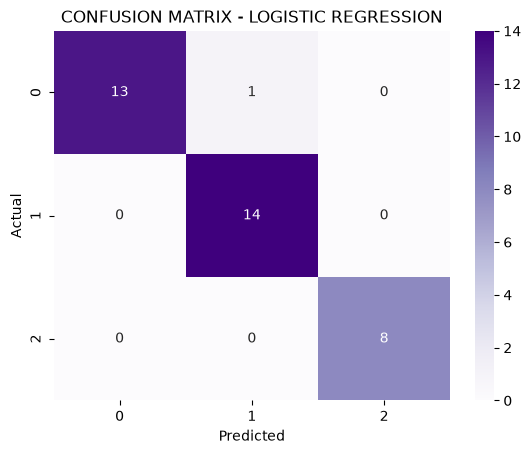

In [71]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels = [0,1,2],
            yticklabels = [0,1,2])
plt.title('CONFUSION MATRIX - LOGISTIC REGRESSION')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [72]:
accuracy = accuracy_score(y_test, y_pred)

- # **Save Model:**

In [73]:
model_bundle = {
    'model' : model,
    'target_names' : ['class 0', 'class 1', 'class 2'],
    'accuracy' : accuracy,
    'version' : '1.0.0'
}
model_path = Path('model.pkl')

joblib.dump(model_bundle, model_path)

print(f'Model Accuracy:{accuracy:4f}')
print(f'Model Saved to:{model_path}')

Model Accuracy:0.972222
Model Saved to:model.pkl
